In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")

In [ ]:
df

,x,y
0,-0.250920,2.574699
1,0.901429,101.050273
2,0.463988,24.285346
3,0.197317,1.915087
4,-0.687963,-0.357155
...,...,...
95,-0.012409,1.652933
96,0.045466,5.649574
97,-0.144918,4.530604
98,-0.949162,1.325820


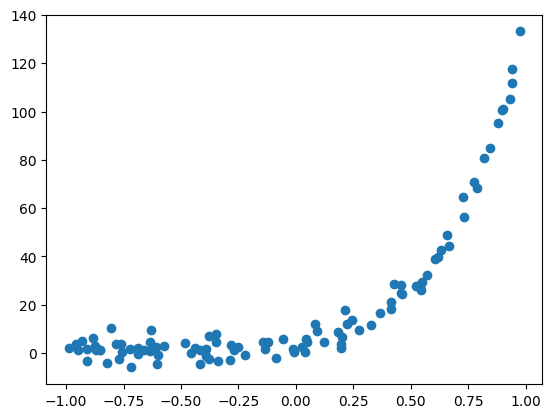

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["x"], df["y"])

# ML


In [ ]:
import numpy as np
x_poly = np.stack([df["x"].values**(i+1) for i in range(2)], axis=1)
x_poly

array([[-2.50919762e-01,  6.29607271e-02],
       [ 9.01428613e-01,  8.12573544e-01],
       [ 4.63987884e-01,  2.15284756e-01],
       [ 1.97316968e-01,  3.89339860e-02],
       [-6.87962719e-01,  4.73292703e-01],
       [-6.88010959e-01,  4.73359080e-01],
       [-8.83832776e-01,  7.81160375e-01],
       [ 7.32352292e-01,  5.36339879e-01],
       [ 2.02230023e-01,  4.08969824e-02],
       [ 4.16145156e-01,  1.73176791e-01],
       [-9.58831011e-01,  9.19356908e-01],
       [ 9.39819704e-01,  8.83261077e-01],
       [ 6.64885282e-01,  4.42072438e-01],
       [-5.75321779e-01,  3.30995149e-01],
       [-6.36350066e-01,  4.04941406e-01],
       [-6.33190980e-01,  4.00930818e-01],
       [-3.91515514e-01,  1.53284398e-01],
       [ 4.95128633e-02,  2.45152363e-03],
       [-1.36109963e-01,  1.85259220e-02],
       [-4.17541720e-01,  1.74341088e-01],
       [ 2.23705789e-01,  5.00442802e-02],
       [-7.21012279e-01,  5.19858706e-01],
       [-4.15710703e-01,  1.72815389e-01],
       [-2.

In [ ]:
x_poly.shape

(100, 2)

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(x_poly, df["y"])


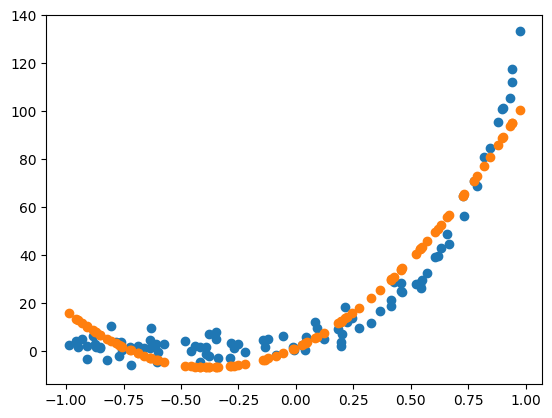

In [ ]:
plt.scatter(df["x"], df["y"])
plt.scatter(df["x"], reg.predict(x_poly))

In [ ]:
reg.coef_, reg.intercept_

(array([44.11435526, 59.26208079]), np.float64(1.1508106929403041))

In [ ]:
import torch

a = torch.tensor([[5.], [3.]], requires_grad=True)
b = torch.tensor(4., requires_grad=True)

f = lambda x: x @ a + b


In [ ]:
a, b

(tensor([[5.],
         [3.]], requires_grad=True),
 tensor(4., requires_grad=True))

In [ ]:
a.shape

torch.Size([2, 1])

In [ ]:
x_poly_tensor = torch.tensor(x_poly[:2], dtype=torch.float32)
y_pred = f(x_poly_tensor)

In [ ]:
loss = ((y_pred - df["y"]) ** 2).mean()

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [ ]:
x_poly[0][0] * 5 + x_poly[0][1] * 3 + 4

np.float64(2.934283369819632)

In [ ]:
x_poly[1][0] * 5 + x_poly[1][1] * 3 + 4


np.float64(10.944863696130025)

In [ ]:
# x (m, n)
# a (n, 1)

In [ ]:
X = torch.tensor(df["x"], dtype=torch.float32)
y = torch.tensor(df["y"]).float()

In [ ]:
X_poly = torch.stack([X**(i) for i in range(1, 3)], dim=-1)
X_poly.shape

torch.Size([100, 2])

In [ ]:
import torch

w = torch.tensor([[5.], [3.]], requires_grad=True)
b = torch.tensor(4., requires_grad=True)

f = lambda x: x @ w + b


In [ ]:
y_pred = f(X_poly[2:4])

In [ ]:
loss = ((y_pred - y[2:4])**2).mean()

In [ ]:
loss

tensor(175.8973, grad_fn=<MeanBackward0>)

In [ ]:
w.grad, b.grad

(tensor([[-24.5747],
         [-36.2854]]),
 tensor(-89.7458))

In [ ]:
loss.backward()

In [ ]:
w.grad, b.grad

(tensor([[-28.9989],
         [-37.9174]]),
 tensor(-103.8771))

In [ ]:
lr = 0.001
with torch.no_grad():
  w -= lr * w.grad
  b -= lr * b.grad

In [ ]:
import torch

w = torch.tensor([[5.], [3.]], requires_grad=True)
b = torch.tensor(4., requires_grad=True)

f = lambda x: x @ w + b


In [ ]:
# y_pred.shape, y.shape
# (y_pred - y).shape

In [ ]:
np.random.choice(6, size=6, replace=False)

array([1, 0, 3, 5, 2, 4])

In [ ]:
def train(f, params, lr, X, y, epochs, criterion):
  assert len(y.shape) == 2, "y shape must be 2d"
  losses = []
  for epoch in range(epochs):
    y_pred = f(X)
    loss = criterion(y_pred, y)
    loss.backward()
    with torch.no_grad():
      for p in params:
        p -= lr * p.grad
        p.grad.zero_()
    if (epoch % 1000) == 0:
      print(f"{epoch:03d}. loss: {loss.item():0.03f}")
    losses.append(loss.item())
  return losses

In [ ]:
w = torch.tensor([[5.], [3.]], requires_grad=True)
b = torch.tensor(4., requires_grad=True)

f = lambda x: x @ w + b

losses = train(f, [w, b], lr=0.01, X=X_poly, y=y.reshape(-1, 1), epochs=10000, criterion=lambda y_pred, y: ((y_pred - y)**2).mean())

000. loss: 1031.078
1000. loss: 92.183
2000. loss: 81.597
3000. loss: 81.104
4000. loss: 81.081
5000. loss: 81.080
6000. loss: 81.080
7000. loss: 81.080
8000. loss: 81.080
9000. loss: 81.080


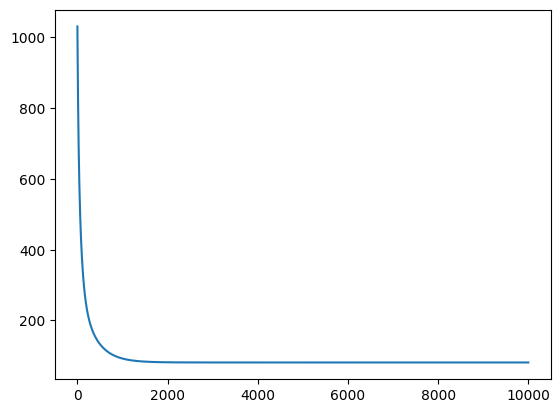

In [ ]:
plt.plot(losses)

In [ ]:
w, b

(tensor([[44.1140],
         [59.2609]], requires_grad=True),
 tensor(1.1512, requires_grad=True))

In [ ]:
(array([44.11435526, 59.26208079]), np.float64(1.1508106929403041))

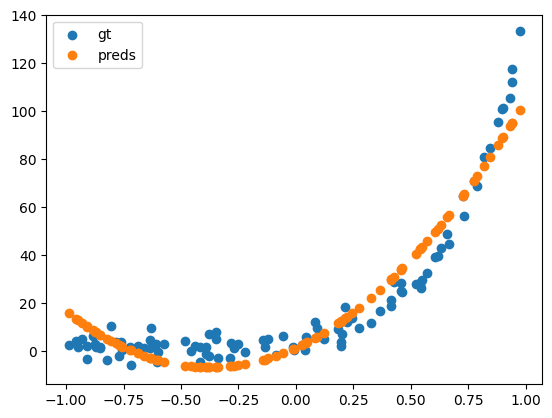

In [ ]:
with torch.no_grad():
  y_pred = f(X_poly)
  plt.scatter(X, y, label="gt")
  plt.scatter(X, y_pred, label="preds")
plt.legend()

In [ ]:
f1 = lambda x: a*torch.exp(x)
f2 = lambda x: a*torch.exp(x) + b*x + c
f3 = lambda x: a*torch.exp(b*x)+c

In [ ]:
# X

000. loss: 1153.757
1000. loss: 1072.107
2000. loss: 1072.107
3000. loss: 1072.107
4000. loss: 1072.107
5000. loss: 1072.107
6000. loss: 1072.107
7000. loss: 1072.107
8000. loss: 1072.107
9000. loss: 1072.107


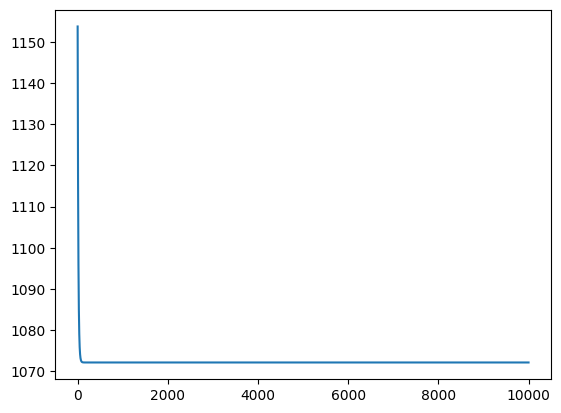

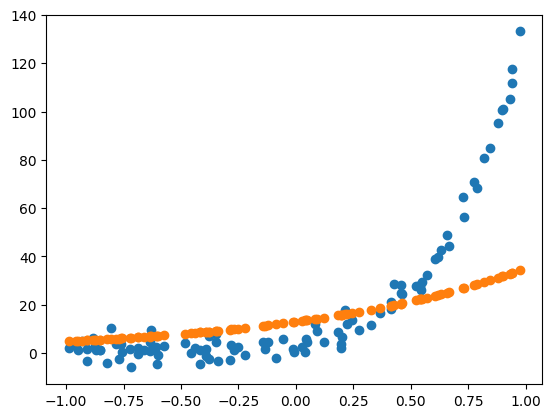

In [ ]:
# f1

a = torch.tensor(6.0, requires_grad=True)
f1 = lambda x: a*torch.exp(x)
criterion = lambda y_pred, y: ((y_pred - y)**2).mean()


losses = train(f1, [a], lr=0.01, X=X, y=y.reshape(-1, 1), epochs=10000, criterion=criterion)
plt.plot(losses)
plt.figure()
plt.scatter(X, y, label="gt")
with torch.no_grad():
  y_pred = f1(X)
plt.scatter(X, y_pred, label="preds")


000. loss: 1081.110
1000. loss: 975.225
2000. loss: 975.138
3000. loss: 975.073
4000. loss: 975.024
5000. loss: 974.987
6000. loss: 974.959
7000. loss: 974.938
8000. loss: 974.922
9000. loss: 974.910


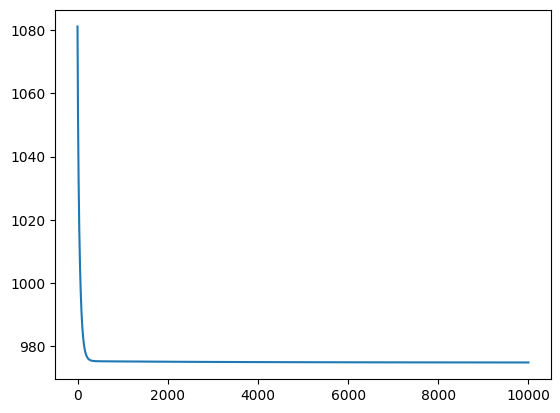

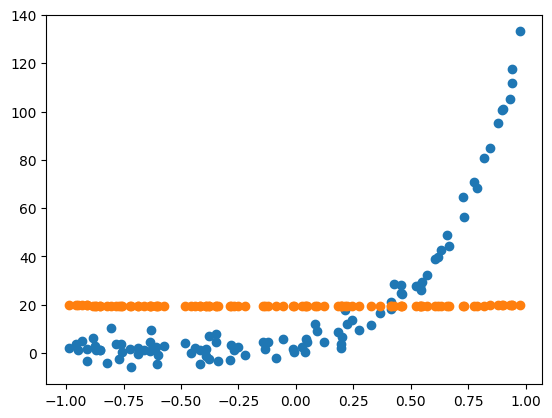

In [ ]:
# f2

a = torch.tensor(6.0, requires_grad=True)
b = torch.tensor(6.0, requires_grad=True)
c = torch.tensor(6.0, requires_grad=True)
f2 = lambda x: a*torch.exp(x) + b*x + c
criterion = lambda y_pred, y: ((y_pred - y)**2).mean()


losses = train(f2, [a, b, c], lr=0.01, X=X, y=y.reshape(-1, 1), epochs=10000, criterion=criterion)
plt.plot(losses)
plt.figure()
plt.scatter(X, y, label="gt")
with torch.no_grad():
  y_pred = f2(X)
plt.scatter(X, y_pred, label="preds")


In [ ]:
a, b, c

(tensor(9.3367, requires_grad=True),
 tensor(-0.0095, requires_grad=True),
 tensor(9.6998, requires_grad=True))

000. loss: 1378.325
1000. loss: 975.101
2000. loss: 974.873
3000. loss: 974.873
4000. loss: 974.873
5000. loss: 974.873
6000. loss: 974.873
7000. loss: 974.873
8000. loss: 974.873
9000. loss: 974.873


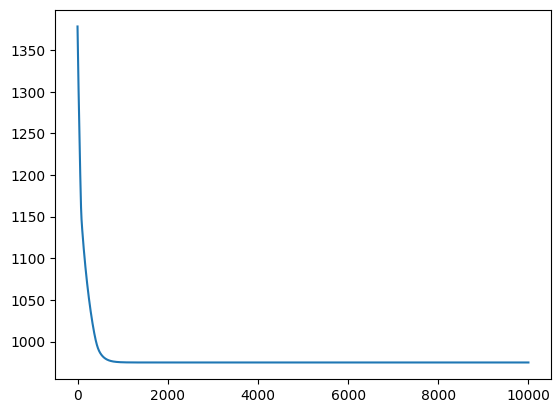

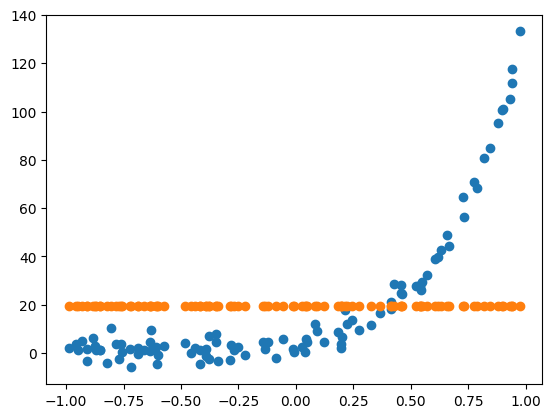

In [ ]:
# f3

a = torch.randn((1,), requires_grad=True)
b = torch.randn((1,), requires_grad=True)
c = torch.randn((1,), requires_grad=True)
f3 = lambda x: a*torch.exp(b*x)+c
criterion = lambda y_pred, y: ((y_pred - y)**2).mean()


losses = train(f3, [a, b, c], lr=0.001, X=X, y=y.reshape(-1, 1), epochs=10000, criterion=criterion)
plt.plot(losses)
plt.figure()
plt.scatter(X, y, label="gt")
with torch.no_grad():
  y_pred = f3(X)
plt.scatter(X, y_pred, label="preds")


In [ ]:
def train_mbgd(f, params, lr, X, y, epochs, criterion, bs=32, random_state=42):
  assert len(y.shape) == 2, "y shape must be 2d"
  rng = np.random.RandomState(random_state)
  losses = []
  params_vals = []
  for epoch in range(epochs):
    epoch_loss = 0
    n_minibatches = 0
    indexes = rng.choice(len(X), size=len(X), replace=False)
    for i in range(0, len(X), bs):
      X_batch = X[indexes[i:i+bs]]
      y_batch = y[indexes[i:i+bs]]
      y_pred = f(X_batch)
      loss = criterion(y_pred, y_batch)
      loss.backward()
      with torch.no_grad():
        for p in params:
          p -= lr * p.grad
          p.grad.zero_()
      epoch_loss += loss.item()
      n_minibatches += 1
    epoch_loss /= n_minibatches
    params_vals.append([p.item() for p in params])
    if (epoch % 1000) == 0:
      print(f"{epoch:03d}. loss: {epoch_loss:0.03f}")
    losses.append(epoch_loss)
  return losses, params_vals

In [ ]:
X.shape, y.shape


(torch.Size([100]), torch.Size([100]))

000. loss: 1146.150
1000. loss: 16.543
2000. loss: 11.091
3000. loss: 16.132
4000. loss: 12.135
5000. loss: 15.935
6000. loss: 11.829
7000. loss: 11.224
8000. loss: 12.479
9000. loss: 11.300
10000. loss: 12.212
11000. loss: 14.756
12000. loss: 13.103
13000. loss: 11.412
14000. loss: 10.984
15000. loss: 17.473
16000. loss: 10.927
17000. loss: 11.894
18000. loss: 15.984
19000. loss: 11.557


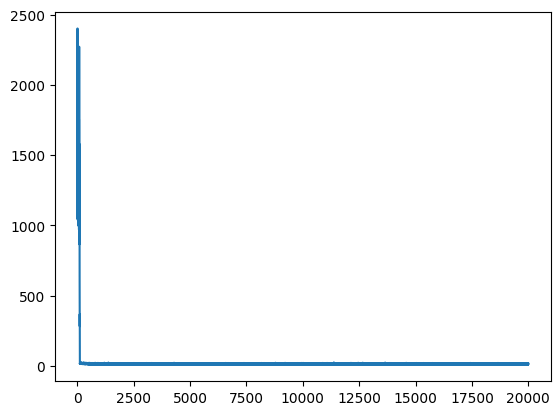

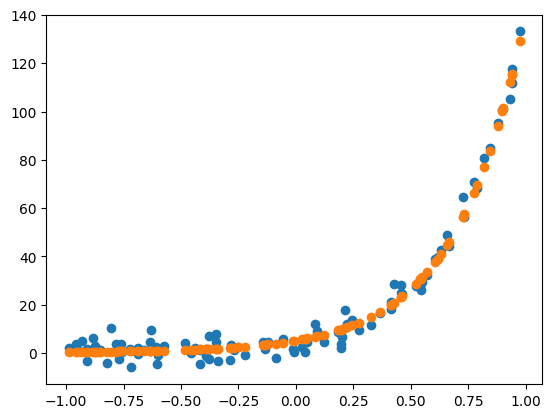

In [ ]:
# f3

a = torch.tensor(0.01, requires_grad=True)
b = torch.tensor(0.1, requires_grad=True)
c = torch.tensor(0.1, requires_grad=True)
f3 = lambda x: a*torch.exp(b*x)+c
criterion = lambda y_pred, y: ((y_pred - y)**2).mean()


losses, params_vals = train_mbgd(f3, [a, b, c], lr=0.0001, X=X.reshape(-1, 1), y=y.reshape(-1, 1), epochs=20000, criterion=criterion, bs=32)
plt.plot(losses)
plt.figure()
plt.scatter(X, y, label="gt")
with torch.no_grad():
  y_pred = f3(X)
plt.scatter(X, y_pred, label="preds")


In [ ]:
a, b, c

(tensor(4.8691, requires_grad=True),
 tensor(3.3656, requires_grad=True),
 tensor(0.3014, requires_grad=True))

000. loss: 1142.756
1000. loss: 381.623
2000. loss: 286.350
3000. loss: 284.236
4000. loss: 232.487
5000. loss: 275.235
6000. loss: 304.374
7000. loss: 235.220
8000. loss: 216.102
9000. loss: 231.095
10000. loss: 244.798
11000. loss: 252.102
12000. loss: 221.649
13000. loss: 231.988
14000. loss: 223.607
15000. loss: 238.015
16000. loss: 192.160
17000. loss: 213.827
18000. loss: 356.612
19000. loss: 190.266


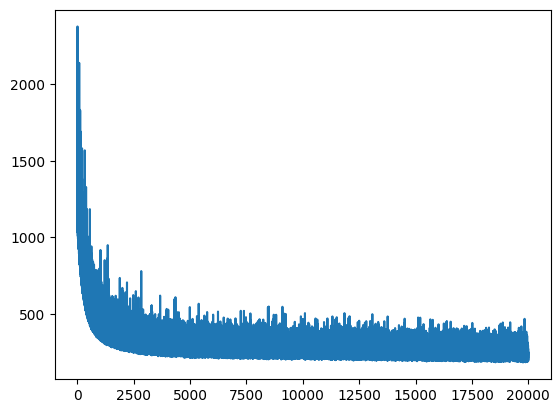

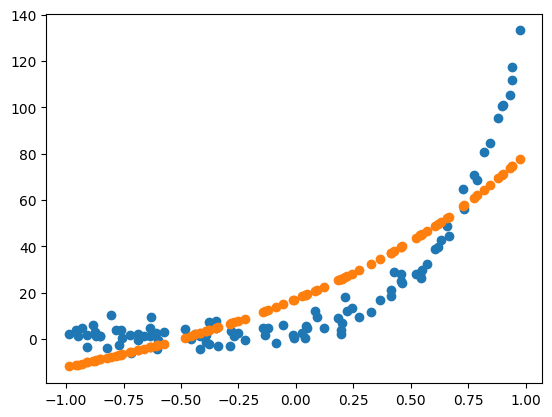

In [ ]:
# f2

a = torch.tensor(0.01, requires_grad=True)
b = torch.tensor(0.1, requires_grad=True)
c = torch.tensor(0.1, requires_grad=True)
f2 = lambda x: a*torch.exp(x) + b*x + c
criterion = lambda y_pred, y: ((y_pred - y)**2).mean()


losses, params_vals = train_mbgd(f2, [a, b, c], lr=0.0001, X=X.reshape(-1, 1), y=y.reshape(-1, 1), epochs=20000, criterion=criterion, bs=32)
plt.plot(losses)
plt.figure()
plt.scatter(X, y, label="gt")
with torch.no_grad():
  y_pred = f2(X)
plt.scatter(X, y_pred, label="preds")


000. loss: 1149.067
1000. loss: 405.078
2000. loss: 352.281
3000. loss: 381.770
4000. loss: 335.204
5000. loss: 380.552
6000. loss: 478.826
7000. loss: 354.626
8000. loss: 359.483
9000. loss: 339.288
10000. loss: 374.045
11000. loss: 402.535
12000. loss: 369.274
13000. loss: 356.750
14000. loss: 358.836
15000. loss: 344.871
16000. loss: 356.070
17000. loss: 372.616
18000. loss: 629.512
19000. loss: 342.894


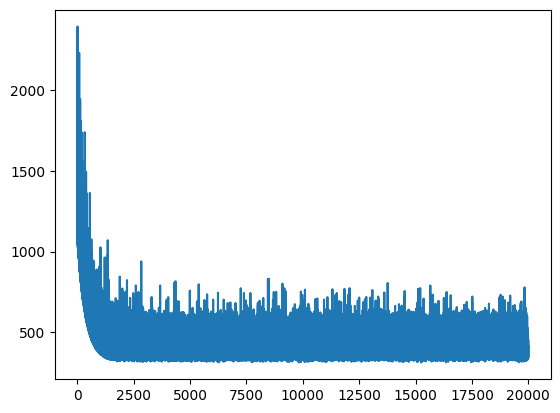

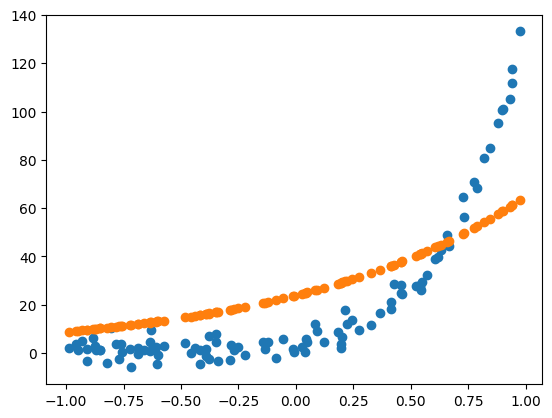

In [ ]:
# f1

a = torch.tensor(0.01, requires_grad=True)
# b = torch.tensor(0.1, requires_grad=True)
# c = torch.tensor(0.1, requires_grad=True)
f1 = lambda x: a*torch.exp(x)
criterion = lambda y_pred, y: ((y_pred - y)**2).mean()


losses, params_vals = train_mbgd(f1, [a], lr=0.0001, X=X.reshape(-1, 1), y=y.reshape(-1, 1), epochs=20000, criterion=criterion, bs=32)
plt.plot(losses)
plt.figure()
plt.scatter(X, y, label="gt")
with torch.no_grad():
  y_pred = f1(X)
plt.scatter(X, y_pred, label="preds")


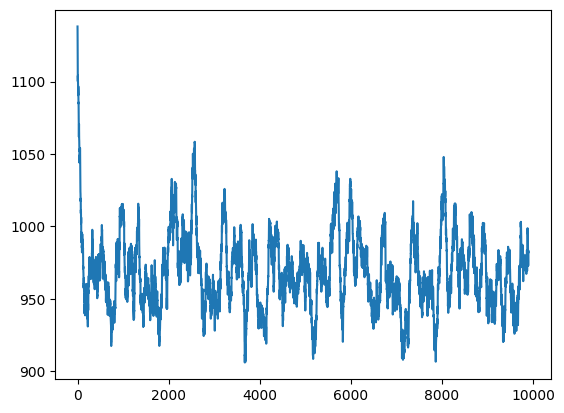

In [ ]:
plt.plot([np.mean(losses[i:i+100]) for i in range(0, len(losses)-100)])


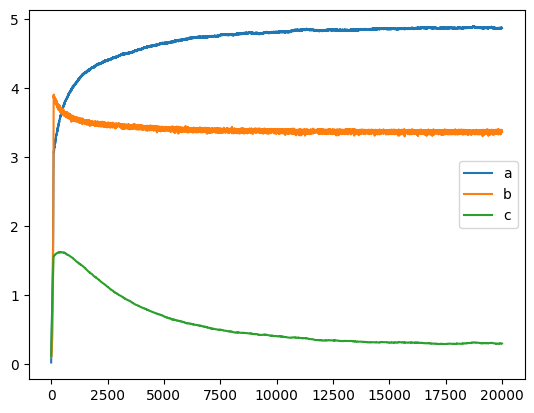

In [ ]:
plt.plot([x[0] for x in params_vals], label="a")
plt.plot([x[1] for x in params_vals], label="b")
plt.plot([x[2] for x in params_vals], label="c")

plt.legend()

In [ ]:
a = torch.tensor(0.1, requires_grad=True)
b = torch.tensor(2.0, requires_grad=True)
c = torch.tensor(1.0, requires_grad=True)
y = a * torch.exp(b * 1) + c
loss = ((y - 7)**2).mean()
loss.backward()


In [ ]:
X = torch.tensor(df["x"], dtype=torch.float32)
y = torch.tensor(df["y"]).float()

In [ ]:
from torch import nn

class ModelExp(nn.Module):
  def __init__(self):
    super().__init__()
    self.a = nn.Parameter(torch.tensor(0.1), requires_grad=True)
    self.b = nn.Parameter(torch.tensor(0.1), requires_grad=True)
    self.c = nn.Parameter(torch.tensor(0.1), requires_grad=True)

  def forward(self, x):
    return self.a * torch.exp(self.b * x) + self.c

In [ ]:
model_exp = ModelExp()

In [ ]:
from torch import optim

optimizer = optim.Adam(model_exp.parameters(), lr=0.001)

In [ ]:
def train_pt(model, optimizer, bs):
  losses = []
  for epoch in range(10000):
    y_preds = model_exp(X.reshape(-1, 1))
    loss = ((y.reshape(-1, 1) - y_preds)**2).mean()
    loss.backward()
    # break
    optimizer.step()
    optimizer.zero_grad()
    losses.append(loss.item())


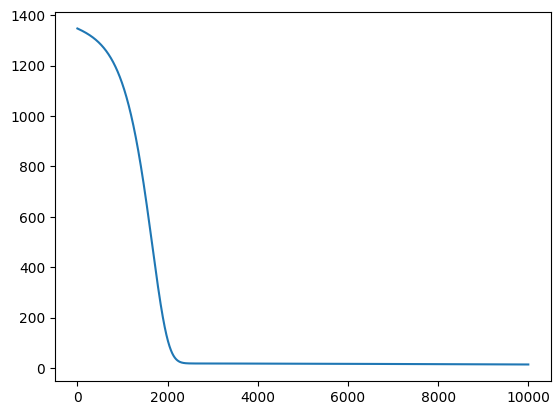

In [ ]:
plt.plot(losses)

In [ ]:
model_exp.a, model_exp.b, model_exp.c

(Parameter containing:
 tensor(4.2088, requires_grad=True),
 Parameter containing:
 tensor(3.5278, requires_grad=True),
 Parameter containing:
 tensor(1.0636, requires_grad=True))

In [ ]:
def train_mbgd_pt(model, optimizer, X, y, epochs, criterion, bs=32, random_state=42):
  assert len(y.shape) == 2, "y shape must be 2d"
  rng = np.random.RandomState(random_state)
  losses = []
  for epoch in range(epochs):
    epoch_loss = 0
    n_minibatches = 0
    indexes = rng.choice(len(X), size=len(X), replace=False)
    for i in range(0, len(X), bs):
      X_batch = X[indexes[i:i+bs]]
      y_batch = y[indexes[i:i+bs]]
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      epoch_loss += loss.item()
      n_minibatches += 1
    epoch_loss /= n_minibatches
    if (epoch % 1000) == 0:
      print(f"{epoch:03d}. loss: {epoch_loss:0.03f}")
    losses.append(epoch_loss)
  return losses

In [ ]:
losses = train_mbgd_pt(model_exp, optimizer, X.reshape(-1, 1), y.reshape(-1, 1), 10000, criterion=lambda y_preds, y: ((y_preds - y)**2).mean())

000. loss: 1142.993
1000. loss: 16.348
2000. loss: 13.098
3000. loss: 16.310
4000. loss: 11.740
5000. loss: 15.961
6000. loss: 12.180
7000. loss: 11.222
8000. loss: 12.445
9000. loss: 11.045


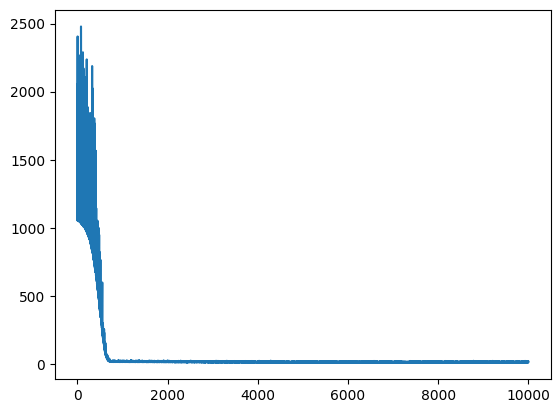

In [ ]:
plt.plot(losses)

In [ ]:
class ModelLR(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.l1 = nn.Linear(n_features, 1)

  def forward(self, x):
    return self.l1(x)

In [ ]:
model_lr = ModelLR(1)
optimizer = optim.Adam(model_lr.parameters(), lr=0.001)
losses = train_mbgd_pt(model_lr, optimizer, X.reshape(-1, 1), y.reshape(-1, 1), 10000, criterion=lambda y_preds, y: ((y_preds - y)**2).mean())


000. loss: 1162.782
1000. loss: 905.045
2000. loss: 779.006
3000. loss: 660.746
4000. loss: 600.174
5000. loss: 509.920
6000. loss: 765.494
7000. loss: 417.098
8000. loss: 434.083
9000. loss: 361.823


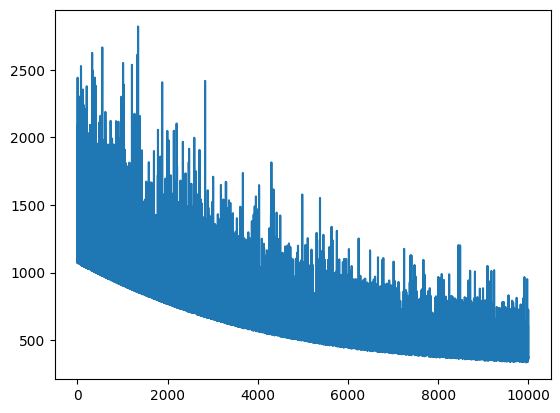

In [ ]:
plt.plot(losses)
plt.figure()
with torch.no_grad():
  y_preds = model_lr(X.reshape(-1, 1))
  plt.scatter(X, y.flatten())
  plt.scatter(X, y_preds.flatten())


In [ ]:
y_preds.shape

torch.Size([100, 1])

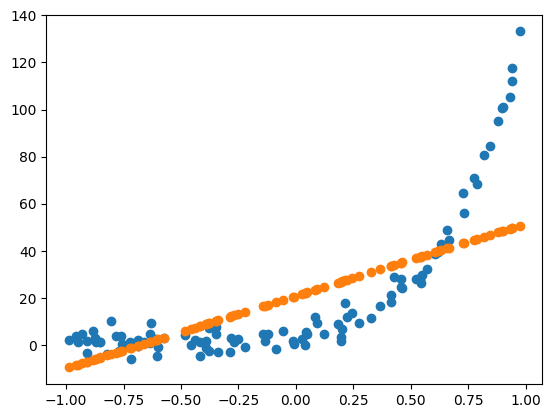

In [ ]:
y = a * b * b2 * x

In [ ]:
n_features = 10
n_hidden = 100

layer = nn.Linear(n_features, n_hidden)
# n_neurons? 100
# n_parameters? 11 * 100 = 1100

In [ ]:
layer.weight.nelement() + layer.bias.nelement()

1100

In [ ]:
class ModelMLP(nn.Module):
  def __init__(self, n_features, n_hidden, n_layers=2):
    super().__init__()
    self.layers = nn.ModuleList(
        [
            nn.Linear(n_features if i == 0 else n_hidden, n_hidden)
            for i in range(n_layers-1)
        ]
    )
    self.l_final = nn.Linear(n_hidden, 1)

  def forward(self, x):
    for layer in self.layers:
      x = layer(x)
      x = torch.sigmoid(x)
    x = self.l_final(x)
    return x

In [ ]:
model_mlp = ModelMLP(1, n_hidden=100, n_layers=5)
optimizer = optim.Adam(model_mlp.parameters(), lr=0.001)
losses = train_mbgd_pt(model_mlp, optimizer, X.reshape(-1, 1), y.reshape(-1, 1), 10000, criterion=lambda y_preds, y: ((y_preds - y)**2).mean())


000. loss: 1148.561
1000. loss: 19.649
2000. loss: 10.117
3000. loss: 16.357
4000. loss: 9.523
5000. loss: 14.627
6000. loss: 12.400
7000. loss: 9.265
8000. loss: 11.187
9000. loss: 14.384


In [ ]:
model_mlp.l1.weight.shape

torch.Size([100, 1])

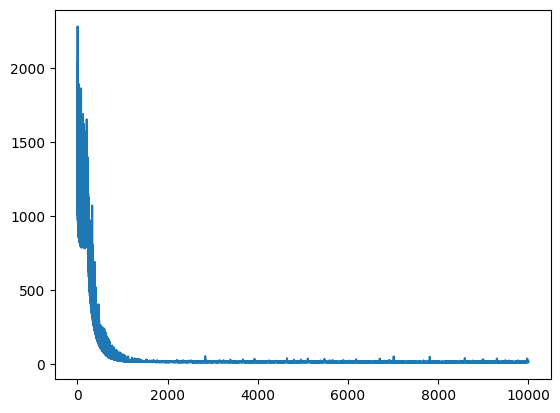

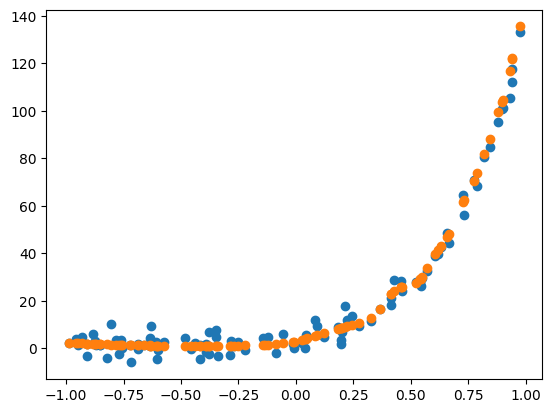

In [ ]:
plt.plot(losses)
plt.figure()
with torch.no_grad():
  y_preds = model_mlp(X.reshape(-1, 1))
  plt.scatter(X, y.flatten())
  plt.scatter(X, y_preds.flatten())


torch.Size([1, 1])


tensor([[0.2649]], grad_fn=<AddBackward0>)

In [ ]:
y = a exp(b * x) + c

In [ ]:
















y = w1*x1 + w2*x2 + w3*x3 + b

W = [w1, w2, w3]
X = [x1, x2, x3]

y = W (dot) X + b


X -> (1, 3)
W -> (3, 1)

y = X @ W + b



X -> (3, 1)
W -> (1, 3)

y = X.T @ W.T + b
y = (W @ X).T + b